In [ ]:
from pyoxigraph import Store, RdfFormat
from pyproj import Transformer
import json
import matplotlib.pyplot as plt

## Loading

In [4]:
!head -n 50 "data/kotus_names/kotus-names-archive.ttl"

<http://ldf.fi/kotus-names-archive/Q100000003>
        a       <http://ldf.fi/schema/kotus-names-archive/place_type_8597> ;
        <http://ldf.fi/schema/kotus-names-archive/collection>
                "1-kokoelma" ;
        <http://ldf.fi/schema/kotus-names-archive/collector>
                "Norta, Airi" ;
        <http://ldf.fi/schema/kotus-names-archive/name_type>
                "paikannimi" ;
        <http://ldf.fi/schema/kotus-names-archive/parish>
                "Kiuruvesi" ;
        <http://ldf.fi/schema/kotus-names-archive/positioning_accuracy>
                "Kerääjä on sijoittanut merkinnän tähän pisteeseen." ;
        <http://ldf.fi/schema/kotus-names-archive/stamp_date>
                1965 ;
        <http://www.w3.org/2002/07/owl#sameAs>
                <https://nimiarkisto.fi/wiki/Q100000003> ;
        <http://www.w3.org/2003/01/geo/wgs84_pos#lat>
                63.607767 ;
        <http://www.w3.org/2003/01/geo/wgs84_pos#long>
                26.491315 ;
        <ht

In [3]:
STORE_DIR = "data/kotus_names/names_storage"
TTL_FILE = "data/kotus_names/kotus-names-archive.ttl"

In [5]:
store = Store(STORE_DIR)
if len(store) == 0:
    store.bulk_load(path=TTL_FILE, format=RdfFormat.TURTLE)

## Querying

In [6]:
q = """
PREFIX k: <http://ldf.fi/schema/kotus-names-archive/>
SELECT ?nameType (COUNT(?s) AS ?n) WHERE {
  ?s k:name_type ?nameType .
}
GROUP BY ?nameType
ORDER BY DESC(?n)
"""
for row in store.query(q):
    print(row["nameType"].value, row["n"].value)

paikannimi 2097927
nimenosa, virheellinen karttanimi tai muu nimitieto 51554
yleisnimi 39407
henkilönnimi 29360


In [ ]:
transformer = Transformer.from_crs("WGS84", "ETRS-TM35FIN").transform

In [ ]:
q = """
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX wgs:  <http://www.w3.org/2003/01/geo/wgs84_pos#>
PREFIX k:    <http://ldf.fi/schema/kotus-names-archive/>
SELECT ?label ?parish ?type ?lat ?long WHERE {
    VALUES ?type {
        k:place_type_9945 # maakunta
        k:place_type_9946 # kunta
        k:place_type_9952 # pitäjä
        k:place_type_8363 # kyläkunta
        k:place_type_8346 # kylä
        k:place_type_8552 # kaupunginosa
    }
    ?place a ?type ;
        skos:prefLabel ?label ;
        k:stamp_date ?date;
        k:parish ?parish ;
        
        wgs:lat ?lat ;
        wgs:long ?long .
}
ORDER BY ?label ?parish
"""

results = [
    {
        "label": row["label"].value,
        "parish": row["parish"].value,
        "place_type": int(row["type"].value.split("_")[-1]),
        "lat": float(row["lat"].value),
        "lon": float(row["long"].value),
    } for row in store.query(q)
]
for r in results:
    r["lat"], r["lon"] = transformer(r["lat"], r["lon"])

print(len(results))

7657


In [102]:
with open("outputs/json/kotus-places.jsonl", "w") as fp:
    fp.writelines(
        [json.dumps(x, ensure_ascii=False)+"\n" for x in results]
    )

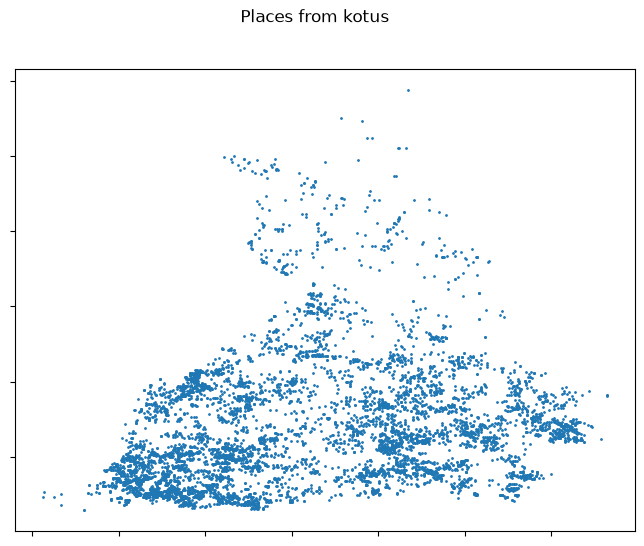

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle("Places from kotus")

ax.set_yticklabels([])
ax.set_xticklabels([])

ax.scatter(
    y=[r["lon"] for r in results],
    x=[r["lat"] for r in results],
    s=1
)